# Import libraries

In [72]:
import numpy as np 
import pandas as pd 
import os
import missingno as msno
import seaborn as sns

# import data

In [73]:
def read_data(path):
    files = os.listdir(path)
    grouped = {}
    for f in files:
        if not f.endswith('.png'):
            prefix = f.split('_')[0]
            grouped.setdefault(prefix, []).append(f)
            grouped[prefix].sort()
    
    pairs = [filenames for filenames in grouped.values() if len(filenames) == 2]

    dfs = []
    for p1, p2 in pairs: 
        prefix = p1.split('_')[0]
        temp_df = pd.DataFrame({})
        temp_df['id'] = prefix
        df1 = pd.read_csv(path+p1)
        df2 = pd.read_csv(path+p2)
        df1 = df1.rename(columns = {'GR': 'GR_h'})
        df2 = df2.rename(columns = {'GR': 'GR_v', 'TVT': 'TVT_v'})
        temp_df = pd.concat([df1, df2], axis = 1)
        temp_df.insert(0, 'id', prefix)
        dfs.append(temp_df)

    result_df = pd.concat(dfs, ignore_index = True)
    return result_df

In [74]:
path_train = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/'
path_test = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/'

train_df = read_data(path_train)
test_df = read_data(path_test)

In [75]:
train_df

,id,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR_h,TVT_input,TVT_v,GR_v,Geology
0,75d20a82,11394.00,2923616.01,1016054.69,-9299.47,-9808.28,-10034.85,-10073.75,-10149.14,-10195.99,-10355.21,11065.12,126.46,11065.12,11052.95,124.99,OLMOS
1,75d20a82,11395.00,2923616.00,1016054.68,-9300.47,-9808.24,-10034.81,-10073.71,-10149.10,-10195.95,-10355.17,11066.16,NaN,11066.16,11053.45,126.44,OLMOS
2,75d20a82,11396.00,2923615.98,1016054.68,-9301.47,-9808.20,-10034.77,-10073.67,-10149.06,-10195.91,-10355.14,11067.20,133.59,11067.20,11053.95,129.21,OLMOS
3,75d20a82,11397.00,2923615.97,1016054.67,-9302.47,-9808.16,-10034.73,-10073.63,-10149.02,-10195.87,-10355.10,11068.24,136.48,11068.24,11054.45,130.38,OLMOS
4,75d20a82,11398.00,2923615.96,1016054.67,-9303.47,-9808.13,-10034.70,-10073.60,-10148.99,-10195.83,-10355.06,11069.28,NaN,11069.28,11054.95,128.66,OLMOS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5101707,99529c45,18039.00,2893694.34,1028439.24,-8985.62,-8560.45,-8795.49,-8854.73,-8889.32,-8909.67,-9044.52,11148.43,NaN,NaN,NaN,NaN,NaN
5101708,99529c45,18040.00,2893693.68,1028439.98,-8985.58,-8560.42,-8795.46,-8854.70,-8889.29,-8909.64,-9044.49,11148.42,101.73,NaN,NaN,NaN,NaN
5101709,99529c45,18041.00,2893693.02,1028440.73,-8985.54,-8560.39,-8795.43,-8854.67,-8889.26,-8909.61,-9044.46,11148.41,NaN,NaN,NaN,NaN,NaN
5101710,99529c45,18042.00,2893692.36,1028441.48,-8985.50,-8560.36,-8795.40,-8854.64,-8889.23,-8909.58,-9044.43,11148.40,NaN,NaN,NaN,NaN,NaN


In [76]:
train_df.isnull().sum()

id                 0
MD              9457
X               9457
Y               9457
Z               9457
ANCC           55091
ASTNU           9457
ASTNL           9457
EGFDU           9457
EGFDL          15524
BUDA            9457
TVT             9457
GR_h         1517429
TVT_input    3793446
TVT_v        3534667
GR_v         3534667
Geology      4058141
dtype: int64

In [77]:
test_df.isnull().sum()

id               0
MD               0
X                0
Y                0
Z                0
GR_h          3784
TVT_input    14151
TVT_v        13423
GR_v         13423
dtype: int64

In [78]:
test_df.shape

(19221, 9)

In [79]:
train_df = train_df.dropna(subset = ['MD', 'X', 'Y', 'Z'])

In [80]:
train_df.isnull().sum()

id                 0
MD                 0
X                  0
Y                  0
Z                  0
ANCC           45634
ASTNU              0
ASTNL              0
EGFDU              0
EGFDL           6067
BUDA               0
TVT                0
GR_h         1507972
TVT_input    3783989
TVT_v        3534667
GR_v         3534667
Geology      4058141
dtype: int64

<Axes: >

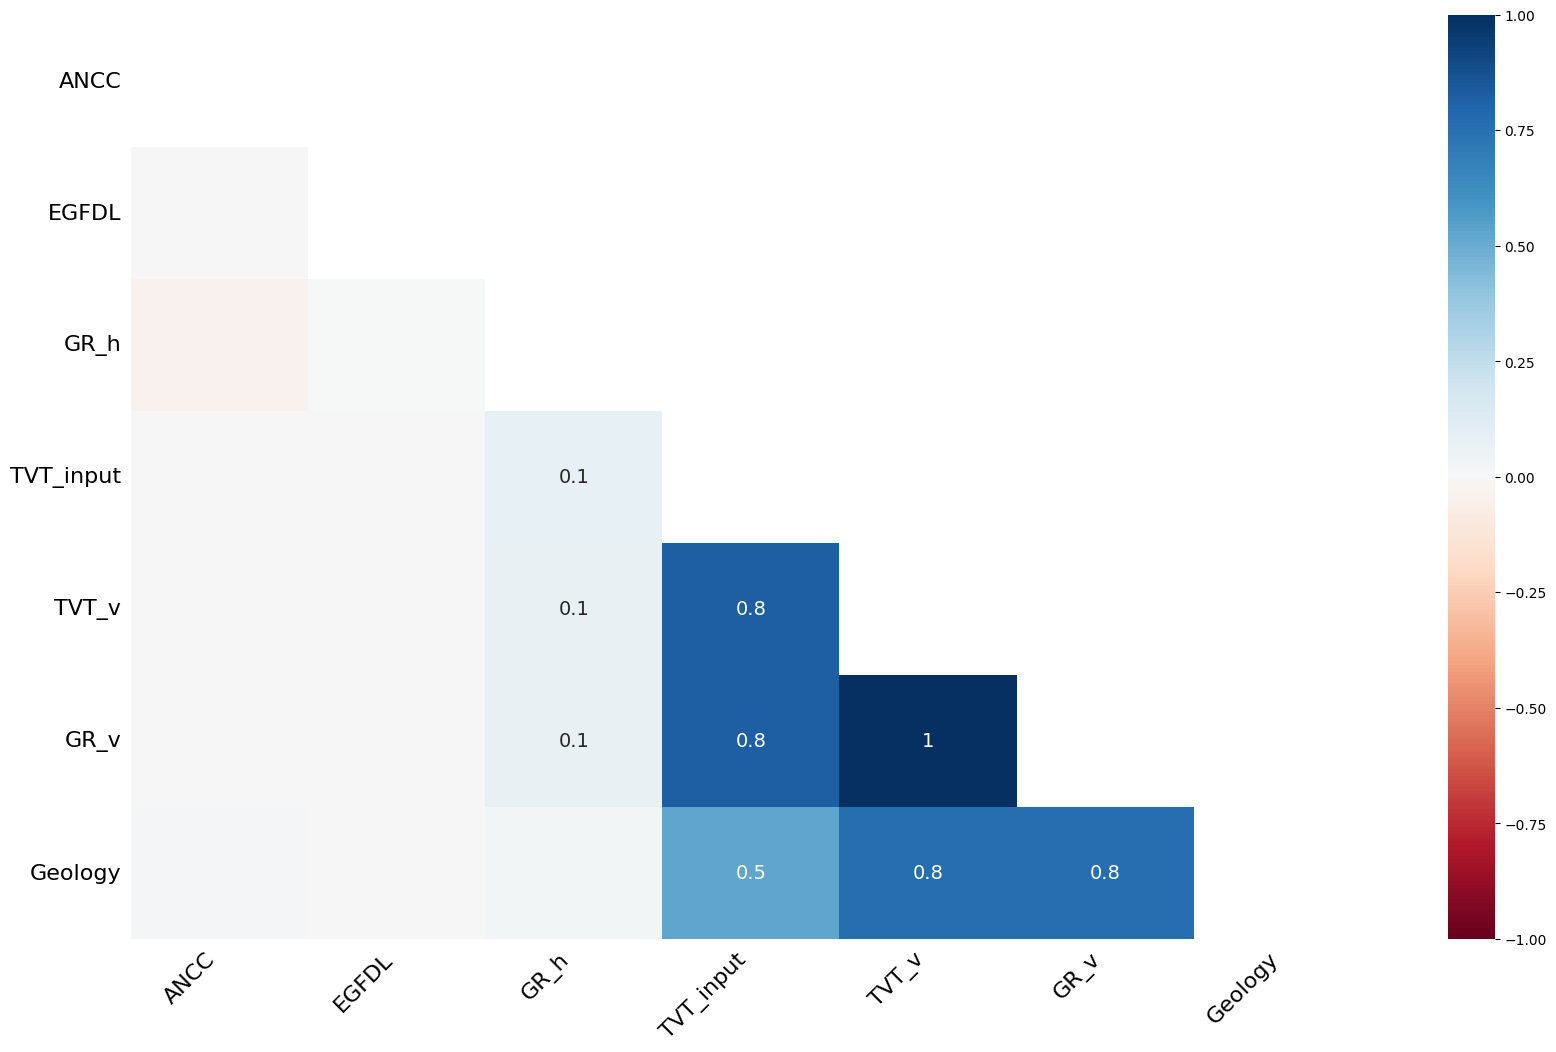

In [81]:
msno.heatmap(train_df)

<Axes: >

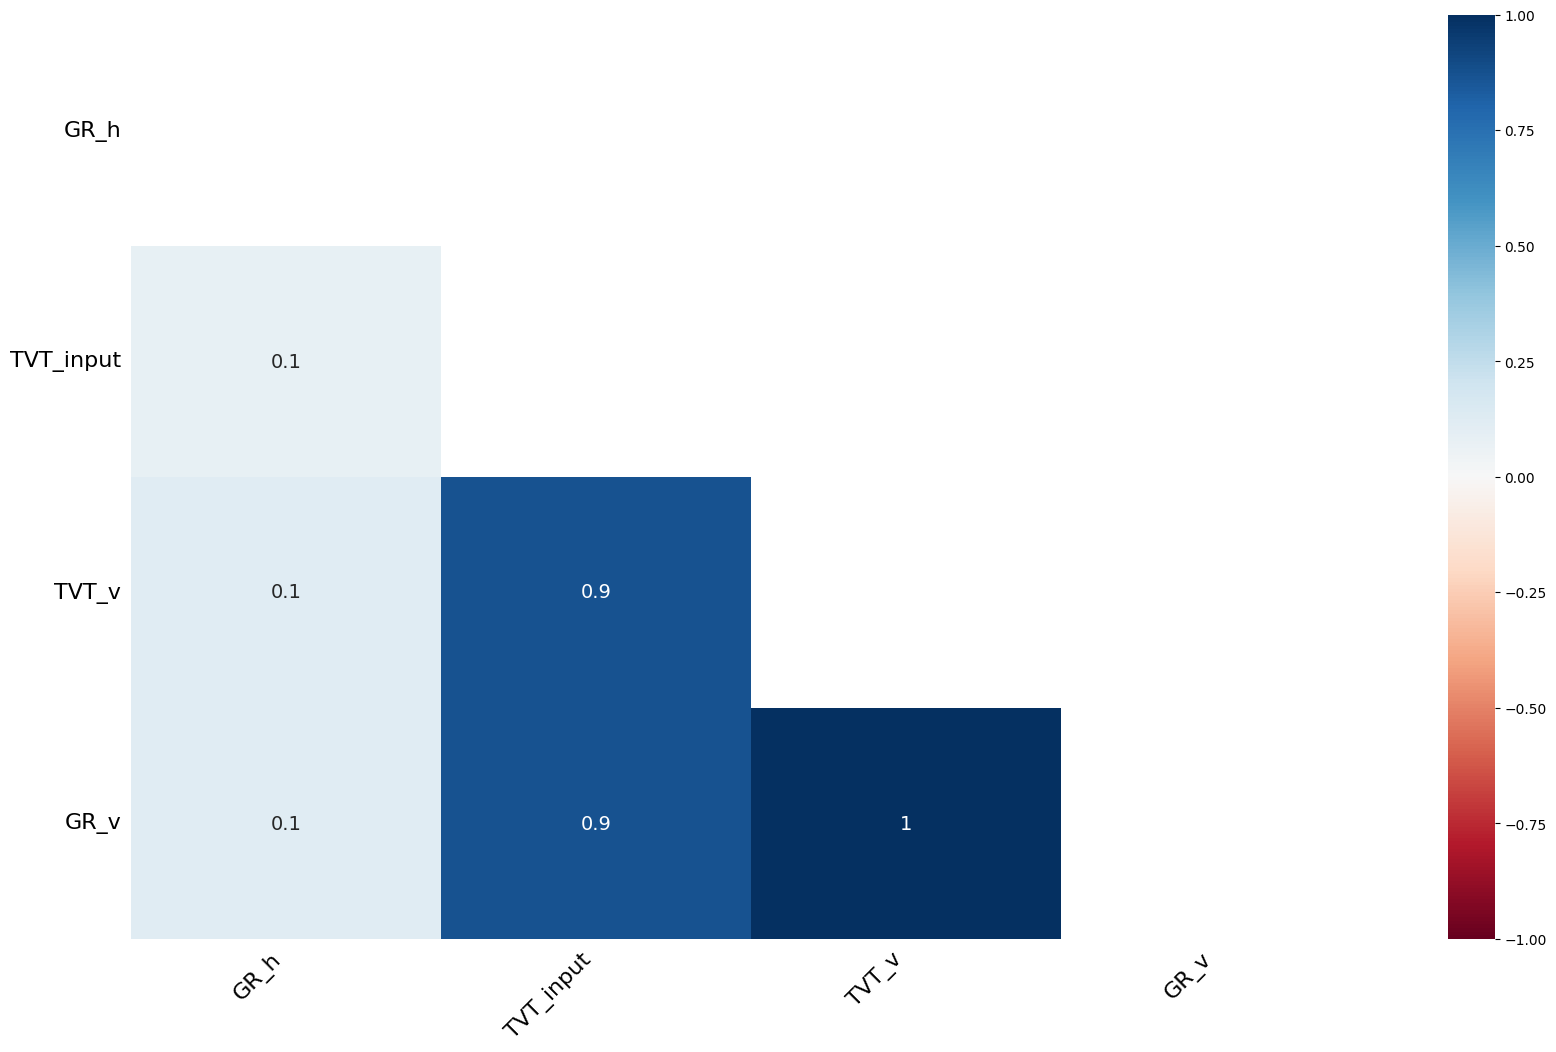

In [82]:
msno.heatmap(test_df)

In [83]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
train_df[['GR_v', 'GR_h']].describe()

,GR_v,GR_h
count,1557588.00,3584283.00
mean,89.31,87.75
std,33.62,23.77
min,18.53,13.88
25%,64.94,72.49
50%,89.94,85.86
75%,110.78,101.04
max,433.58,487.03


<Axes: xlabel='Column', ylabel='Value'>

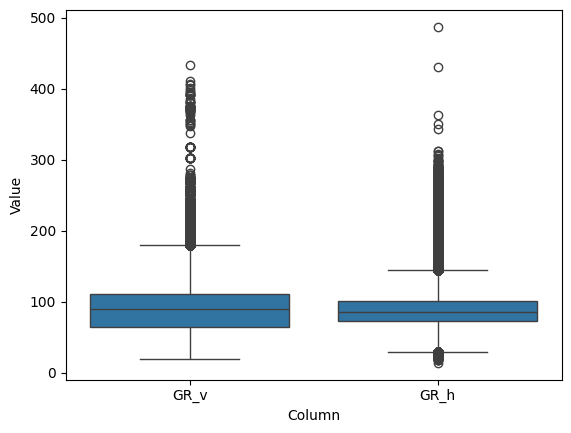

In [84]:
grs = train_df[['GR_v', 'GR_h']].melt(var_name='Column', value_name='Value')
sns.boxplot(grs, x='Column', y = 'Value')

In [85]:
train_df[['X', 'Y', 'Z']].describe()

,X,Y,Z
count,5092255.00,5092255.00,5092255.00
mean,2965999.12,1074747.73,-9390.81
std,47749.98,35603.54,634.48
min,2855426.45,1007175.50,-11027.65
25%,2917842.12,1040715.98,-9920.91
50%,2986283.76,1080802.93,-9270.31
75%,3006569.49,1105966.98,-8918.93
max,3039107.26,1141857.53,-7174.22


In [86]:
test_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v'], dtype='object')

In [87]:
train_df.columns

Index(['id', 'MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL',
       'BUDA', 'TVT', 'GR_h', 'TVT_input', 'TVT_v', 'GR_v', 'Geology'],
      dtype='object')

# data processing

In [88]:
def data_processing(df): 
    df = df.sort_values(by = ['id', 'MD']).reset_index(drop = True)
    if 'ANCC' in df.columns: 
        df = df.drop(['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL','BUDA','Geology'], axis = 1)
    df[['dX', 'dY', 'dZ']] = df.groupby('id')[['X', 'Y', 'Z']].diff()
    dI = np.sqrt(df['dX']**2+df['dY']**2+df['dZ']**2)
    df['theta'] = df['dZ']/dI
    df[['dX', 'dY', 'dZ', 'theta']] = df[['dX', 'dY', 'dZ', 'theta']].bfill()
    return df

In [89]:
train_df_p = data_processing(train_df.copy())
test_df_p = data_processing(test_df.copy())

In [90]:
train_df_p.isnull().sum()

id                 0
MD                 0
X                  0
Y                  0
Z                  0
TVT                0
GR_h         1507972
TVT_input    3783989
TVT_v        3534667
GR_v         3534667
dX                 0
dY                 0
dZ                 0
theta              0
dtype: int64

<Axes: >

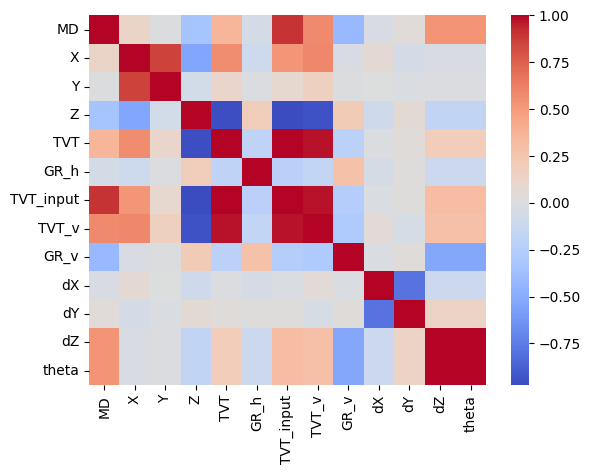

In [91]:
corr_mat = train_df_p.drop('id', axis = 1).corr()
sns.heatmap(corr_mat, cmap = 'coolwarm')

AssertionError: 

np.int64(0)